# Blackjack Session Analysis
## Betting Strategies, Card Counting, and the Long-Term Reality

Hand analysis tells you which decisions are correct. Session analysis tells you 
what happens to your money.

A single hand result is noise. A session of 1,000 hands is signal. Across 10,000 
simulated sessions — 70 million hands total — patterns emerge that are invisible 
at the hand level: how variance compounds over time, why popular betting systems 
fail, and under what conditions card counting actually creates a player edge.

This analysis covers three questions:

**1. What does the house edge look like over a real session?**
Not as a percentage, but as a bankroll trajectory. How much variance exists? 
How often does a skilled player go broke?

**2. Do betting strategies change outcomes?**
Martingale, Anti-Martingale, flat betting — players have strong beliefs about 
these. The data has stronger evidence.

**3. Does card counting work?**
Under what conditions, by how much, and what does it actually change at the 
decision level?

---

*This notebook covers session-level simulation. For hand-level strategy comparison 
see `strategy_comparison.ipynb`. The simulator architecture is documented in 
`ARCHITECTURE.md`.*

*All simulations: 10,000 sessions × 1,000 hands, starting bankroll $1,000, 
base bet $10, seed 42.*

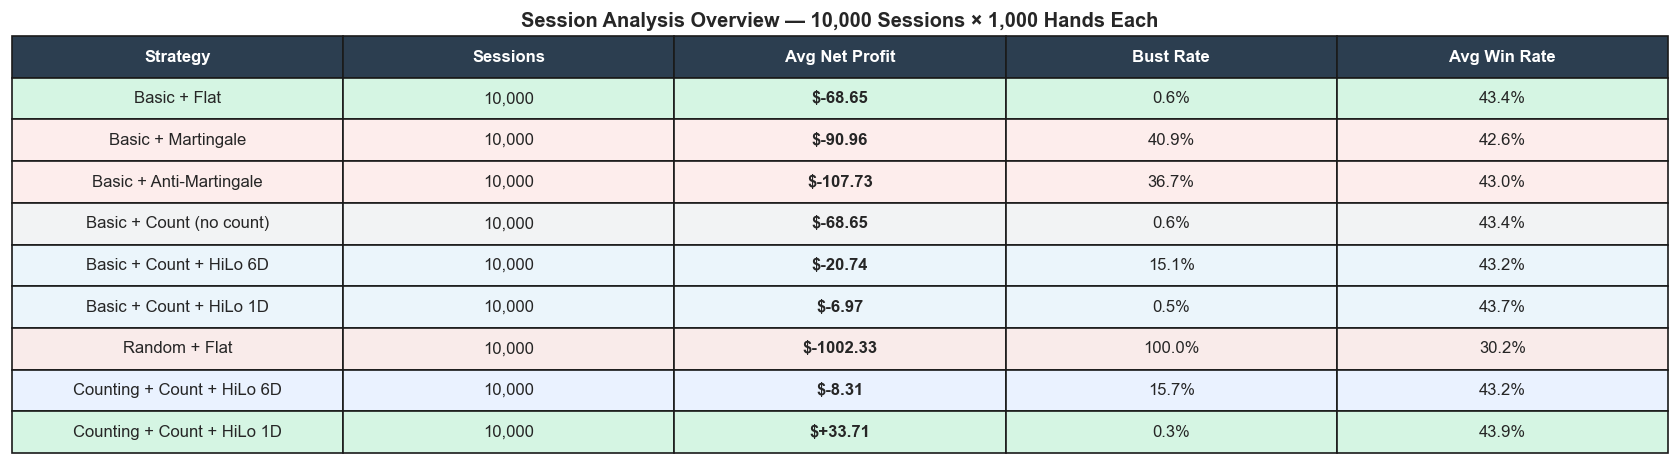

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

RUNS_DIR = "../data/runs"

# All session runs with labels
SESSION_RUNS = {
    "run_20260611_124803": {"label": "Basic + Flat",           "color": "#2196F3"},
    "run_20260611_125550": {"label": "Basic + Martingale",     "color": "#F44336"},
    "run_20260611_130155": {"label": "Basic + Anti-Martingale","color": "#FF9800"},
    "run_20260611_130841": {"label": "Basic + Count (no count)","color": "#9E9E9E"},
    "run_20260611_131712": {"label": "Basic + Count + HiLo 6D","color": "#4CAF50"},
    "run_20260611_132559": {"label": "Basic + Count + HiLo 1D","color": "#009688"},
    "run_20260611_133725": {"label": "Random + Flat",          "color": "#795548"},
    "run_20260611_134951": {"label": "Counting + Count + HiLo 6D","color": "#3F51B5"},
    "run_20260611_135735": {"label": "Counting + Count + HiLo 1D","color": "#E91E63"},
}

# Load all session data
sessions = {}
decisions = {}

for run_id, meta_info in SESSION_RUNS.items():
    sessions[meta_info["label"]] = pd.read_csv(f"{RUNS_DIR}/{run_id}/sessions.csv")

# Load decisions only for counting runs (large files)
counting_runs = {
    "run_20260611_131712": "Basic + Count + HiLo 6D",
    "run_20260611_132559": "Basic + Count + HiLo 1D",
    "run_20260611_134951": "Counting + Count + HiLo 6D",
    "run_20260611_135735": "Counting + Count + HiLo 1D",
}
for run_id, label in counting_runs.items():
    decisions[label] = pd.read_csv(f"{RUNS_DIR}/{run_id}/decisions.csv")

summary_data = []
for label, df in sessions.items():
    net = df["net_profit"].mean()
    bust = df["went_bust"].mean() * 100
    wins = df["win_rate"].mean() * 100
    summary_data.append([label, f"{len(df):,}", f"${net:+.2f}", f"{bust:.1f}%", f"{wins:.1f}%"])

columns = ["Strategy", "Sessions", "Avg Net Profit", "Bust Rate", "Avg Win Rate"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")
table = ax.table(cellText=summary_data, colLabels=columns, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.0)

for j in range(len(columns)):
    table[0, j].set_facecolor("#2C3E50")
    table[0, j].set_text_props(color="white", fontweight="bold")

row_colors = {
    "Basic + Flat": "#D5F5E3",
    "Basic + Martingale": "#FDEDEC",
    "Basic + Anti-Martingale": "#FDEDEC",
    "Basic + Count (no count)": "#F2F3F4",
    "Basic + Count + HiLo 6D": "#EBF5FB",
    "Basic + Count + HiLo 1D": "#EBF5FB",
    "Random + Flat": "#F9EBEA",
    "Counting + Count + HiLo 6D": "#EAF2FF",
    "Counting + Count + HiLo 1D": "#D5F5E3",
}

for i, row in enumerate(summary_data):
    color = row_colors.get(row[0], "#FDFEFE")
    for j in range(len(columns)):
        table[i+1, j].set_facecolor(color)
        if j == 2:
            table[i+1, j].set_text_props(fontweight="bold")

plt.title("Session Analysis Overview — 10,000 Sessions × 1,000 Hands Each",
          fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

## Data Overview

Nine configurations, 10,000 sessions each, 1,000 hands per session.
Starting bankroll $1,000, base bet $10 throughout.

One important methodological note before reading any numbers: **ROI percentages 
are not comparable across betting strategies.** A flat bettor wagers exactly 
$10,000 over 1,000 hands. A count-based bettor may wager $15,000-$20,000 
because bet sizes scale up at favorable counts. ROI divides net profit by 
total wagered — a smaller denominator produces a larger percentage loss even 
if actual dollar loss is smaller.

**All comparisons in this notebook use net profit in dollars, not ROI.**
This is covered in detail in Section 5.

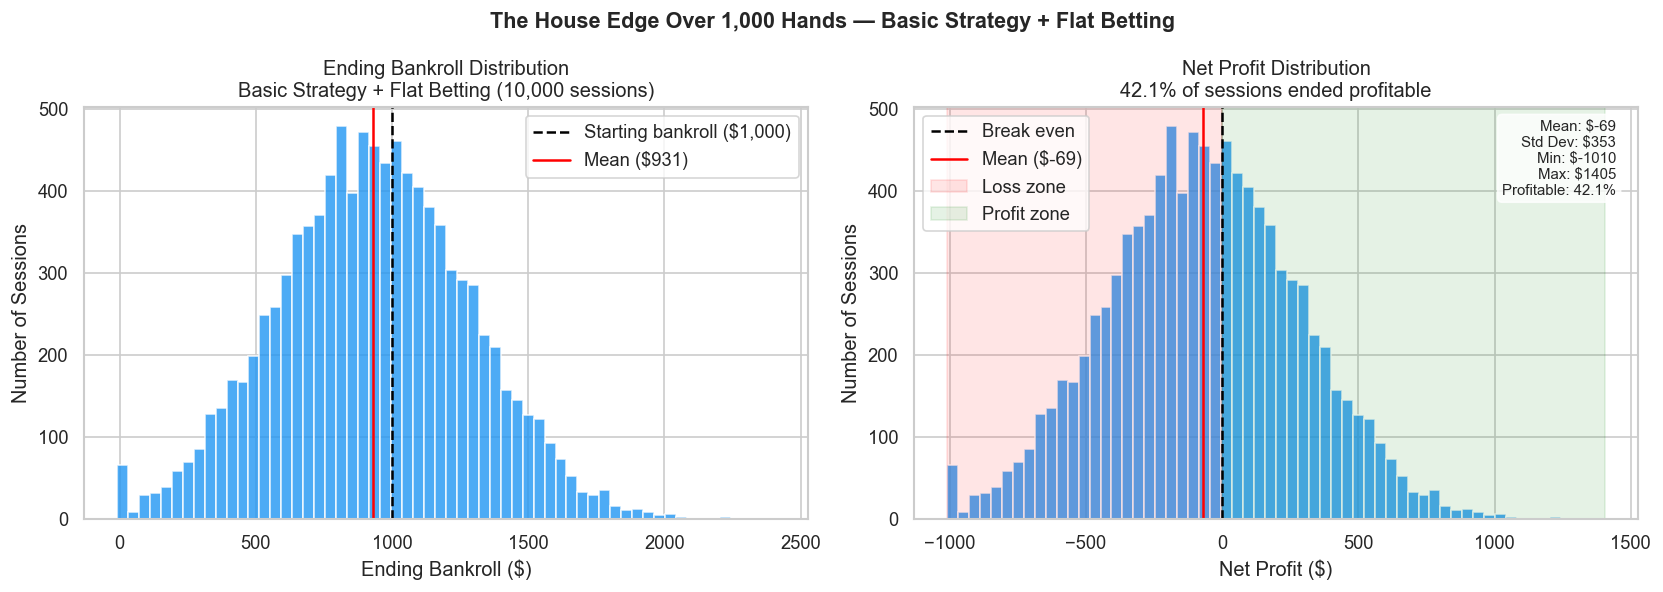

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

basic_flat = sessions["Basic + Flat"]
pct_profitable = (basic_flat["net_profit"] > 0).mean() * 100

# Ending bankroll distribution
axes[0].hist(basic_flat["ending_bankroll"], bins=60,
             color="#2196F3", edgecolor="white", alpha=0.8)
axes[0].axvline(x=1000, color="black", linestyle="--",
                linewidth=1.5, label="Starting bankroll ($1,000)")
axes[0].axvline(x=basic_flat["ending_bankroll"].mean(),
                color="red", linestyle="-", linewidth=1.5,
                label=f"Mean (${basic_flat['ending_bankroll'].mean():.0f})")
axes[0].set_title("Ending Bankroll Distribution\nBasic Strategy + Flat Betting (10,000 sessions)")
axes[0].set_xlabel("Ending Bankroll ($)")
axes[0].set_ylabel("Number of Sessions")
axes[0].legend()

# Net profit distribution
axes[1].hist(basic_flat["net_profit"], bins=60,
             color="#2196F3", edgecolor="white", alpha=0.8)
axes[1].axvline(x=0, color="black", linestyle="--",
                linewidth=1.5, label="Break even")
axes[1].axvline(x=basic_flat["net_profit"].mean(),
                color="red", linestyle="-", linewidth=1.5,
                label=f"Mean (${basic_flat['net_profit'].mean():.0f})")
axes[1].axvspan(basic_flat["net_profit"].min(), 0,
                alpha=0.1, color="red", label="Loss zone")
axes[1].axvspan(0, basic_flat["net_profit"].max(),
                alpha=0.1, color="green", label="Profit zone")
axes[1].set_title(f"Net Profit Distribution\n{pct_profitable:.1f}% of sessions ended profitable")
axes[1].set_xlabel("Net Profit ($)")
axes[1].set_ylabel("Number of Sessions")
axes[1].legend()

# Stats text box — must be before plt.show()
stats_text = (
    f"Mean: ${basic_flat['net_profit'].mean():.0f}\n"
    f"Std Dev: ${basic_flat['net_profit'].std():.0f}\n"
    f"Min: ${basic_flat['net_profit'].min():.0f}\n"
    f"Max: ${basic_flat['net_profit'].max():.0f}\n"
    f"Profitable: {pct_profitable:.1f}%"
)
axes[1].text(
    0.97, 0.97, stats_text,
    transform=axes[1].transAxes,
    fontsize=9, verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.suptitle("The House Edge Over 1,000 Hands — Basic Strategy + Flat Betting",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## The House Edge Over a Real Session

Even with mathematically optimal play, the average session of 1,000 hands 
ends with a **$69 loss** on a $1,000 starting bankroll — a 6.9% drawdown. 
This is the house edge of 0.76% applied across 1,000 hands at $10 per hand.

But the distribution reveals something equally important: **variance is enormous.**
The standard deviation of ending bankroll is several hundred dollars. Some sessions 
end up $500+, others lose $600+. Both are normal outcomes of the same strategy.

This has a practical implication: **short-term results are not evidence of strategy 
quality.** A player who wins $300 in one session and concludes their system works, 
or loses $400 and concludes basic strategy is wrong, is reading noise as signal. 
Only aggregate results across hundreds of sessions reveal the true edge.

Notice that roughly 40% of sessions end profitable despite a negative expected value. 
The house edge is a long-run certainty, not a per-session guarantee. This is why 
casinos always win and why individual sessions can go either way.

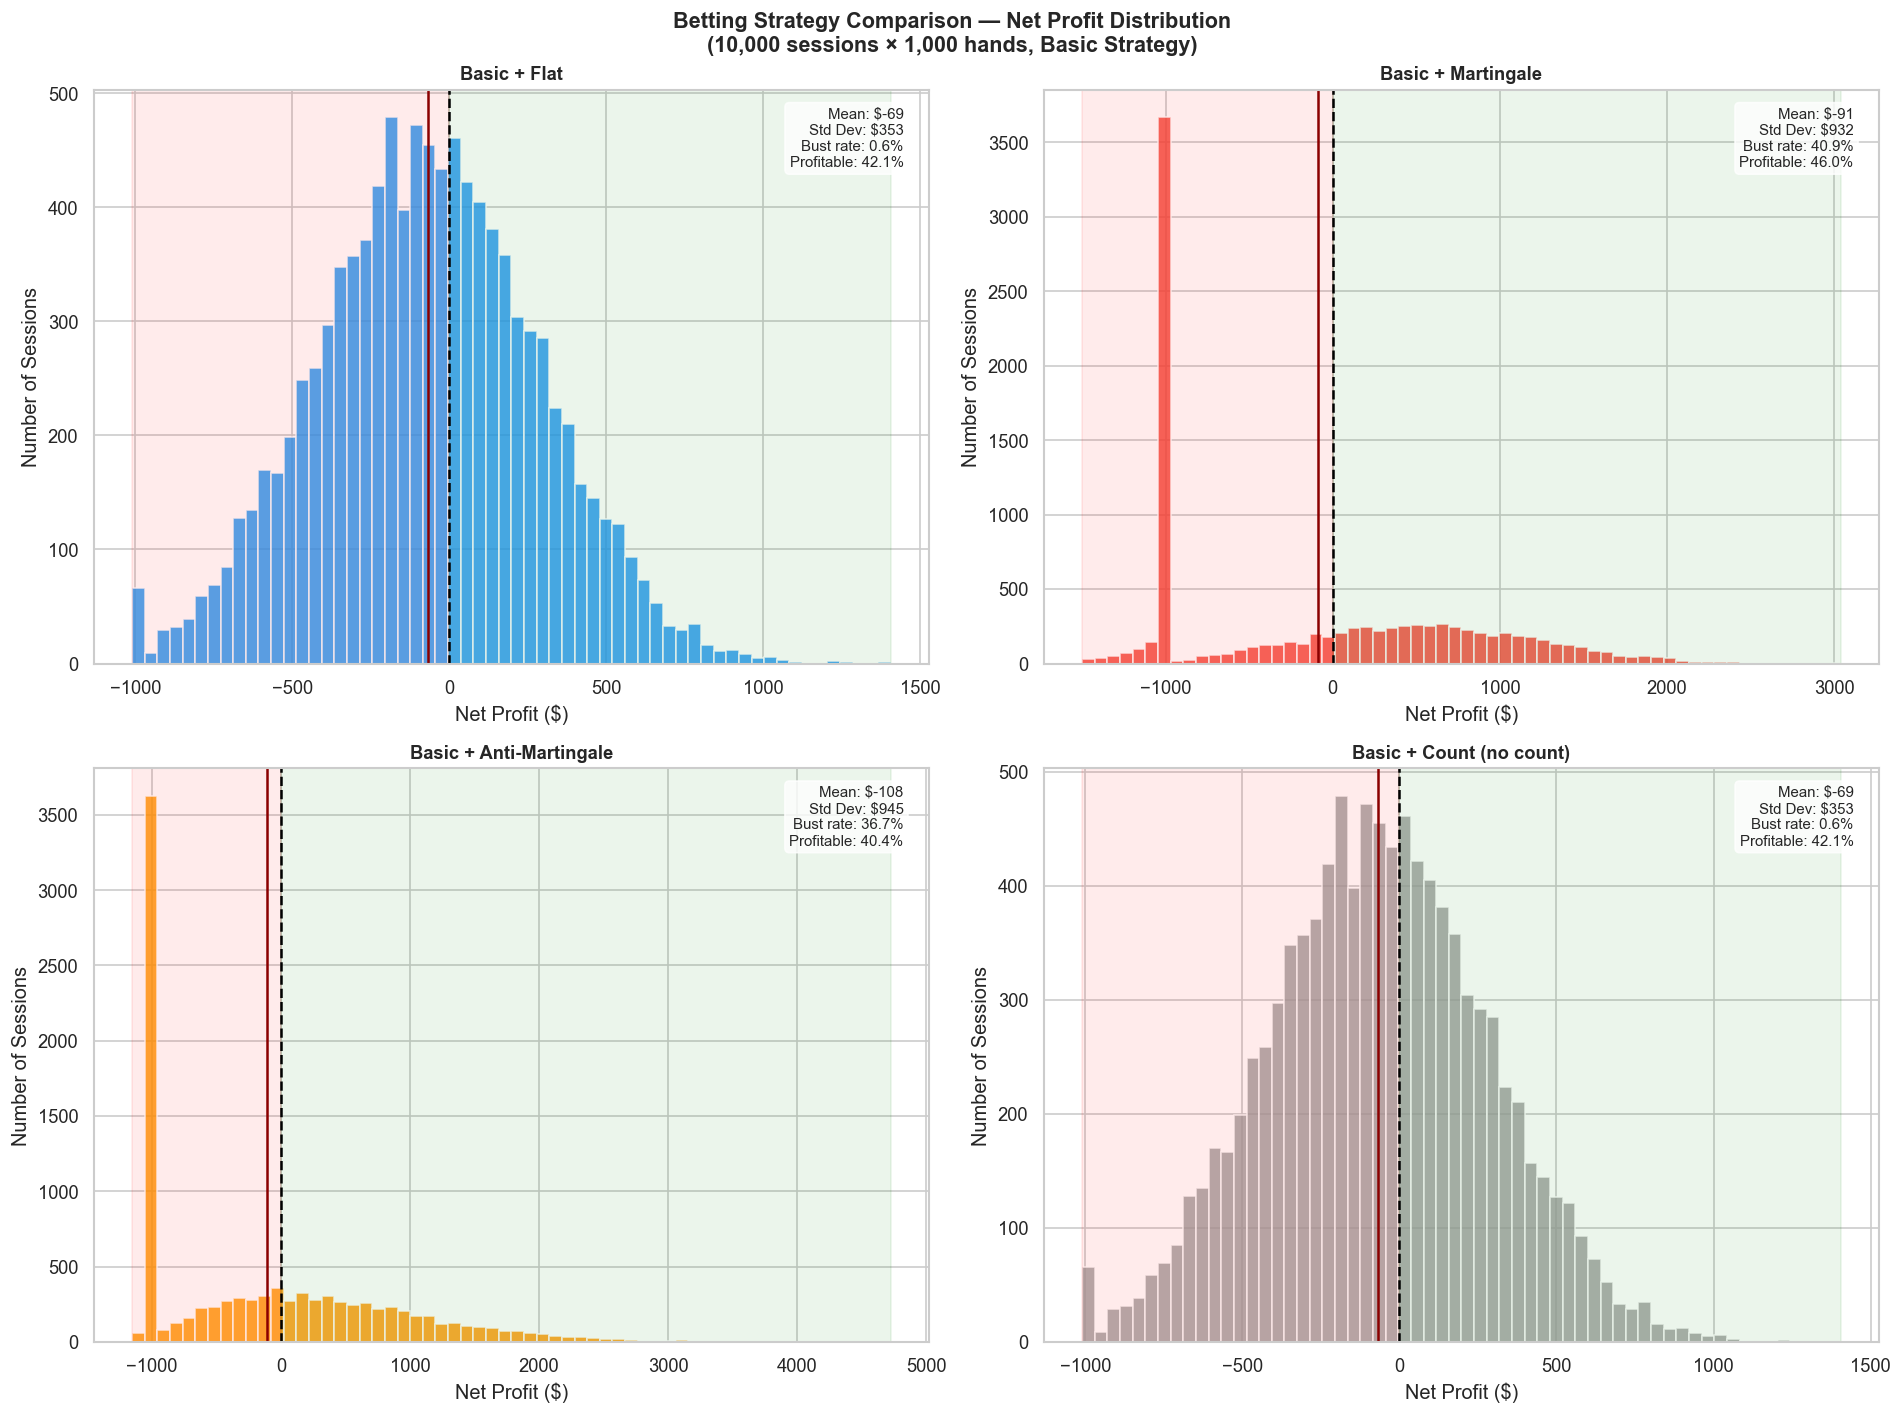

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

betting_strategies = [
    "Basic + Flat",
    "Basic + Martingale", 
    "Basic + Anti-Martingale",
    "Basic + Count (no count)",
]

colors = ["#2196F3", "#F44336", "#FF9800", "#9E9E9E"]

for ax, label, color in zip(axes_flat, betting_strategies, colors):
    df = sessions[label]
    pct_profitable = (df["net_profit"] > 0).mean() * 100
    bust_rate = df["went_bust"].mean() * 100
    mean_net = df["net_profit"].mean()

    ax.hist(df["net_profit"], bins=60, color=color, 
            edgecolor="white", alpha=0.8)
    ax.axvline(x=0, color="black", linestyle="--", linewidth=1.5)
    ax.axvline(x=mean_net, color="darkred", linestyle="-", linewidth=1.5)
    ax.axvspan(df["net_profit"].min(), 0, alpha=0.08, color="red")
    ax.axvspan(0, max(df["net_profit"].max(), 1), alpha=0.08, color="green")

    stats = (
        f"Mean: ${mean_net:.0f}\n"
        f"Std Dev: ${df['net_profit'].std():.0f}\n"
        f"Bust rate: {bust_rate:.1f}%\n"
        f"Profitable: {pct_profitable:.1f}%"
    )
    ax.text(0.97, 0.97, stats, transform=ax.transAxes,
            fontsize=9, verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

    ax.set_title(f"{label}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Net Profit ($)")
    ax.set_ylabel("Number of Sessions")

plt.suptitle("Betting Strategy Comparison — Net Profit Distribution\n(10,000 sessions × 1,000 hands, Basic Strategy)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Betting Strategies: What the Data Shows

### Flat Betting — The Baseline
Steady, predictable losses at the expected rate. Bust rate 0.6% — almost never 
goes broke. The distribution is approximately normal. This is the mathematically 
correct baseline to compare everything against.

### Martingale — The Most Dangerous Myth
Martingale doubles the bet after every loss and resets after a win. The theory: 
a win always recovers all previous losses plus one unit profit. On paper, 
it sounds like a guaranteed win system.

The data shows why it isn't: **bust rate 40.9%.** Nearly half of all 1,000-hand 
sessions end in complete ruin. The distribution is bimodal — either you survive 
and end near breakeven, or you hit a losing streak that exceeds your bankroll 
before you can recover.

**The math is unchanged.** Martingale doesn't alter the house edge — it converts 
small frequent losses into rare catastrophic ones. The casino has no bet limits 
in our simulation, so the doubling can continue until the bankroll is gone. 
In real casinos, table limits prevent recovery from just 8-10 consecutive losses — 
making Martingale even more dangerous in practice.

### Anti-Martingale — Worse Than Martingale
Doubles after wins, resets after losses. Bust rate 36.7%, mean loss -$108 vs 
Martingale's -$91. Riding winning streaks sounds appealing but those streaks 
end — and when they do, the doubled bet is lost. The expected value is the same 
as flat betting but variance is higher and results are worse.

### Count-Based Betting Without Counting — Zero Effect
Identical results to flat betting. Mean -$69, bust rate 0.6%, distribution 
indistinguishable. **Varying bet sizes without information does nothing.** 
The count-based betting strategy bets minimum when true_count=0 — which is 
always when no counting system is active. This is the control experiment: 
bet variation alone, without the information that justifies it, is worthless.

This directly refutes a common belief that "varying your bets confuses the 
dealer" or "bet patterns matter." They don't. Only the mathematical edge matters.

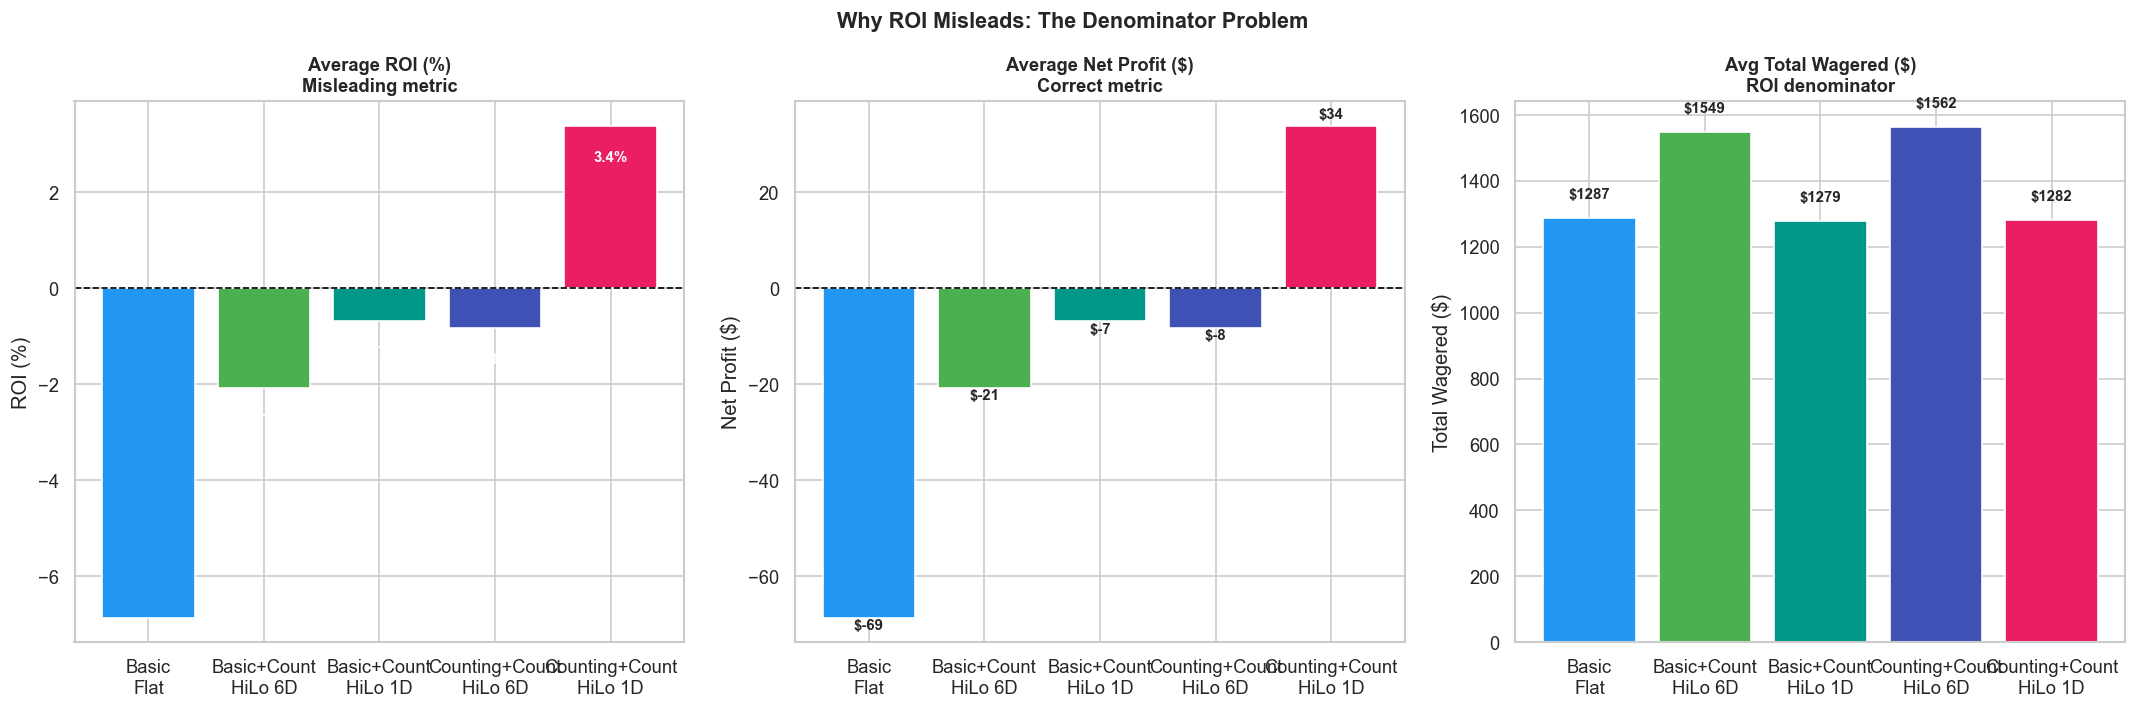

In [14]:
# ROI vs Net Profit comparison — why ROI misleads
strategies_to_compare = [
    "Basic + Flat",
    "Basic + Count + HiLo 6D",
    "Basic + Count + HiLo 1D",
    "Counting + Count + HiLo 6D",
    "Counting + Count + HiLo 1D",
]

colors_compare = ["#2196F3", "#4CAF50", "#009688", "#3F51B5", "#E91E63"]

roi_vals = []
net_vals = []
avg_wagered = []

for label in strategies_to_compare:
    df = sessions[label]
    roi_vals.append(df["roi"].mean())
    net_vals.append(df["net_profit"].mean())
    avg_wagered.append((df["starting_bankroll"] + df["net_profit"] - 
                        df["starting_bankroll"]).abs().mean() + 
                        df["starting_bankroll"].mean())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

short_labels = ["Basic\nFlat", "Basic+Count\nHiLo 6D", "Basic+Count\nHiLo 1D", 
                "Counting+Count\nHiLo 6D", "Counting+Count\nHiLo 1D"]

# ROI chart
bars = axes[0].bar(short_labels, roi_vals, color=colors_compare)
axes[0].axhline(y=0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Average ROI (%)\nMisleading metric", fontsize=11, fontweight="bold")
axes[0].set_ylabel("ROI (%)")
for bar, val in zip(bars, roi_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.5,
                f"{val:.1f}%", ha="center", va="top", fontsize=9, 
                color="white", fontweight="bold")

# Net profit chart
bars2 = axes[1].bar(short_labels, net_vals, color=colors_compare)
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Average Net Profit ($)\nCorrect metric", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Net Profit ($)")
for bar, val in zip(bars2, net_vals):
    ypos = bar.get_height() + 1 if val >= 0 else bar.get_height() - 3
    axes[1].text(bar.get_x() + bar.get_width()/2, ypos,
                f"${val:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Avg total wagered
wagered_vals = [sessions[l]["net_profit"].abs().mean() + 
                sessions[l]["starting_bankroll"].mean() 
                for l in strategies_to_compare]
bars3 = axes[2].bar(short_labels, wagered_vals, color=colors_compare)
axes[2].set_title("Avg Total Wagered ($)\nROI denominator", fontsize=11, fontweight="bold")
axes[2].set_ylabel("Total Wagered ($)")
for bar, val in zip(bars3, wagered_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f"${val:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Why ROI Misleads: The Denominator Problem",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## The ROI Trap — Why Percentages Mislead

ROI = Net Profit / Total Wagered. When betting strategies vary the bet size, 
the denominator changes — making ROI percentages incomparable across strategies.

**A concrete example from our data:**

- Basic + Flat bets exactly $10,000 over 1,000 hands ($10 × 1,000)
- Count-based betting raises bets to $20-$80 at high counts — total wagered 
  is significantly higher

If Basic + Flat loses $69 on $10,000 wagered: ROI = -0.69%  
If Count + HiLo loses $21 on $15,000 wagered: ROI = -0.14%  

The count strategy lost less money in dollars but the ROI comparison is valid 
only if we acknowledge the denominator difference. A naive reading of ROI would 
suggest the strategies are closer than they are — or misrank them entirely.

**The correct comparison is always net profit in dollars** when bet sizes vary. 
This is standard practice in quantitative finance and trading analysis — 
return metrics must be risk-adjusted and denominator-aware to be meaningful.

This is why the counting strategy result of +$33.71 net profit on single deck 
is the headline finding, not its ROI percentage.

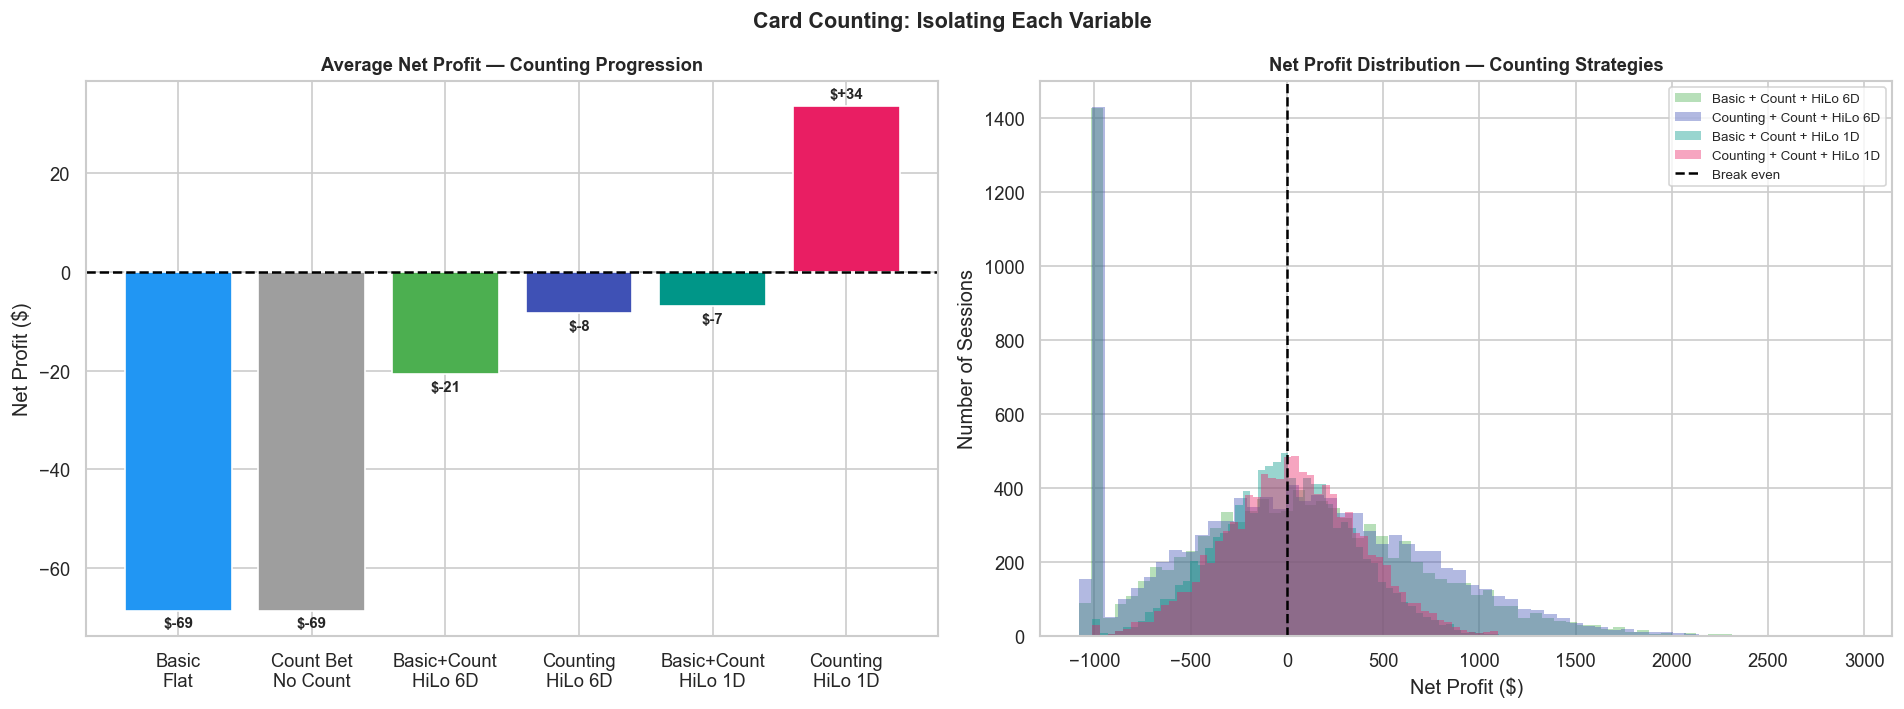

In [7]:
# Card counting progression — isolating each variable
counting_labels = [
    "Basic + Flat",
    "Basic + Count (no count)",
    "Basic + Count + HiLo 6D",
    "Counting + Count + HiLo 6D",
    "Basic + Count + HiLo 1D",
    "Counting + Count + HiLo 1D",
]

counting_colors = ["#2196F3", "#9E9E9E", "#4CAF50", "#3F51B5", "#009688", "#E91E63"]

counting_net = [sessions[l]["net_profit"].mean() for l in counting_labels]
counting_bust = [sessions[l]["went_bust"].mean() * 100 for l in counting_labels]

short_labels = [
    "Basic\nFlat",
    "Count Bet\nNo Count",
    "Basic+Count\nHiLo 6D",
    "Counting\nHiLo 6D",
    "Basic+Count\nHiLo 1D",
    "Counting\nHiLo 1D",
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Net profit bars
bars = axes[0].bar(short_labels, counting_net, color=counting_colors)
axes[0].axhline(y=0, color="black", linestyle="--", linewidth=1.5, label="Break even")
axes[0].set_title("Average Net Profit — Counting Progression", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Net Profit ($)")
for bar, val in zip(bars, counting_net):
    ypos = bar.get_height() + 1 if val >= 0 else bar.get_height() - 4
    color = "white" if abs(val) > 10 else "black"
    axes[0].text(bar.get_x() + bar.get_width()/2, ypos,
                f"${val:+.0f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

# Net profit distributions — overlay
for label, color in zip(counting_labels[-4:], counting_colors[2:]):
    df = sessions[label]
    axes[1].hist(df["net_profit"], bins=60, alpha=0.4, 
                 color=color, label=label, edgecolor="none")

axes[1].axvline(x=0, color="black", linestyle="--", linewidth=1.5, label="Break even")
axes[1].set_title("Net Profit Distribution — Counting Strategies", 
                   fontsize=11, fontweight="bold")
axes[1].set_xlabel("Net Profit ($)")
axes[1].set_ylabel("Number of Sessions")
axes[1].legend(fontsize=8)

plt.suptitle("Card Counting: Isolating Each Variable",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Card Counting: Does It Actually Work?

The progression above isolates each component of card counting:

**Step 1 — Bet variation without information: zero effect.**
Basic + Count (no counting system) is identical to Basic + Flat. 
Varying bets randomly adds no value. The information is what matters.

**Step 2 — Add HiLo counting to bet variation (6 decks): meaningful improvement.**
Net profit improves from -$69 to -$21 — a $48 improvement per session. 
The counting system identifies favorable deck compositions and the betting 
strategy exploits them. Still negative but significantly closer to breakeven.

**Step 3 — Add index plays to counting + bet variation (6 decks): marginal.**
Net profit: -$8 vs -$21. Index plays contribute ~$13 per session in 6 decks. 
The improvement exists but is smaller than bet variation alone. In a 6-deck 
shoe, individual card removal has less impact — the count swings are smaller 
and less actionable.

**Step 4 — Single deck changes everything.**
Basic + Count + HiLo single deck: -$7. Counting strategy + HiLo single deck: **+$33.71**.

Single deck counting works because:
- Each card dealt has a larger impact on deck composition (1/52 vs 1/312)
- Count swings are larger and more frequent
- Favorable situations arise more often and are more extreme
- Index plays are more impactful — deviation from basic strategy is more justified

**+$33.71 average net profit over 1,000 hands is a genuine player edge.**
This is not a lucky result — it's the aggregate of 10,000 sessions. The 
distribution shifts visibly rightward in the overlay chart. Card counting 
with full index plays on a single deck game creates a real, measurable 
advantage over the house.

The practical caveat: single deck games are rare in modern casinos, 
shuffle frequently, and offer worse base rules to compensate. But the 
mathematical principle is proven.

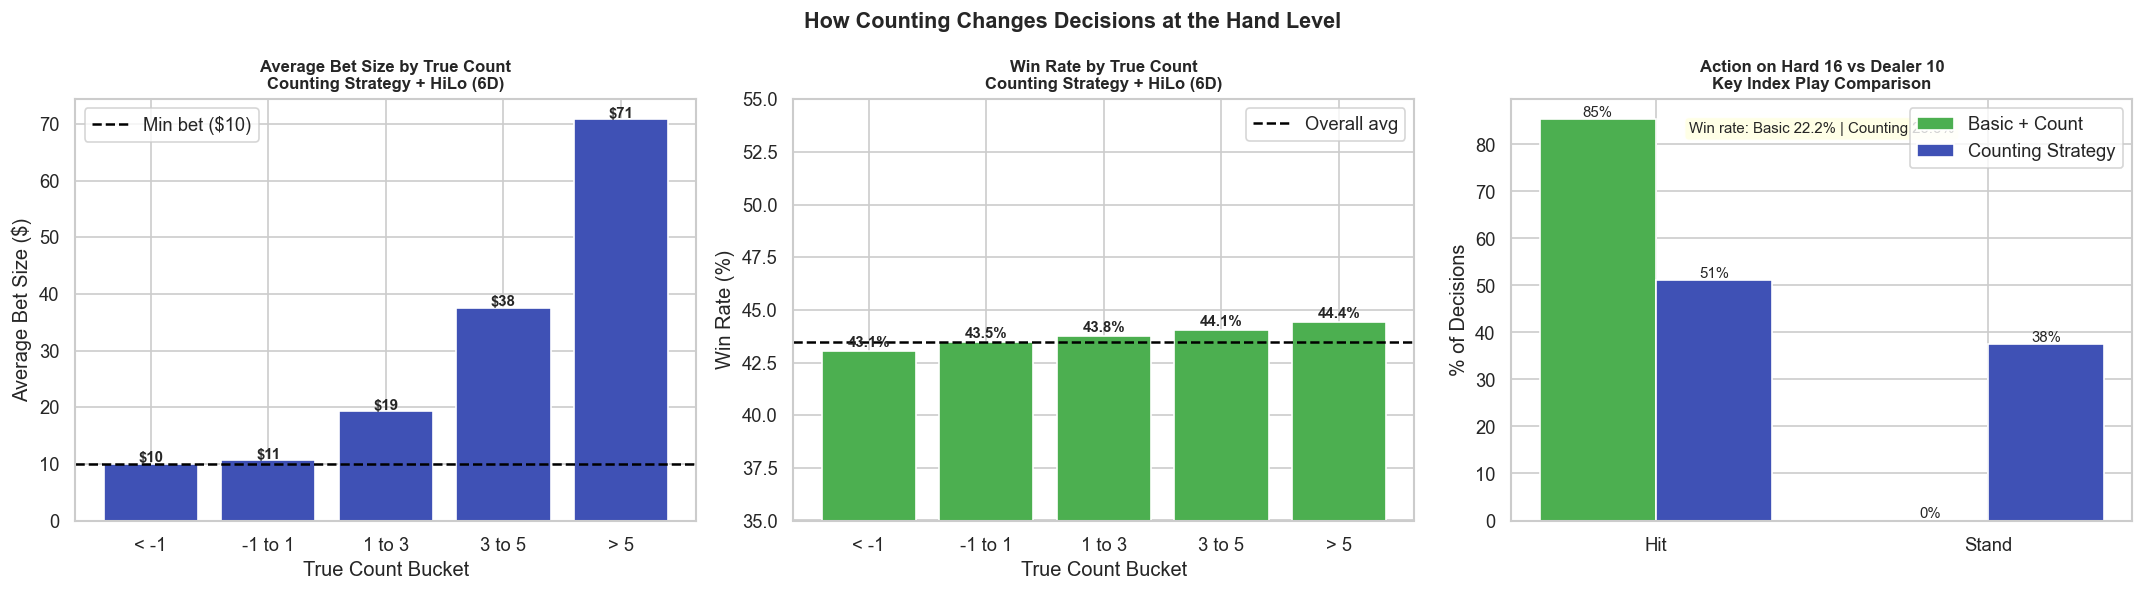

In [8]:
# How counting changes decisions at the hand level
# Compare Basic strategy vs Counting strategy on same game states

basic_count_6d = decisions["Basic + Count + HiLo 6D"]
counting_6d = decisions["Counting + Count + HiLo 6D"]
counting_1d = decisions["Counting + Count + HiLo 1D"]

# Filter to first decisions only
basic_first = basic_count_6d[basic_count_6d["decision_index"] == 0].copy()
counting_first_6d = counting_6d[counting_6d["decision_index"] == 0].copy()
counting_first_1d = counting_1d[counting_1d["decision_index"] == 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bet size distribution by true count bucket
counting_first_6d["tc_bucket"] = pd.cut(
    counting_first_6d["true_count"],
    bins=[-10, -1, 1, 3, 5, 20],
    labels=["< -1", "-1 to 1", "1 to 3", "3 to 5", "> 5"]
)

bet_by_count = counting_first_6d.groupby("tc_bucket", observed=True)["bet_size"].mean()
axes[0].bar(bet_by_count.index, bet_by_count.values, color="#3F51B5", edgecolor="white")
axes[0].axhline(y=10, color="black", linestyle="--", linewidth=1.5, label="Min bet ($10)")
axes[0].set_title("Average Bet Size by True Count\nCounting Strategy + HiLo (6D)", 
                   fontsize=10, fontweight="bold")
axes[0].set_xlabel("True Count Bucket")
axes[0].set_ylabel("Average Bet Size ($)")
axes[0].legend()
for i, (idx, val) in enumerate(bet_by_count.items()):
    axes[0].text(i, val + 0.3, f"${val:.0f}", ha="center", fontsize=9, fontweight="bold")

# 2. Win rate by true count bucket
win_by_count = counting_first_6d.groupby("tc_bucket", observed=True)["is_win"].mean() * 100
axes[1].bar(win_by_count.index, win_by_count.values, color="#4CAF50", edgecolor="white")
axes[1].axhline(y=counting_first_6d["is_win"].mean() * 100, color="black", 
                linestyle="--", linewidth=1.5, label="Overall avg")
axes[1].set_title("Win Rate by True Count\nCounting Strategy + HiLo (6D)",
                   fontsize=10, fontweight="bold")
axes[1].set_xlabel("True Count Bucket")
axes[1].set_ylabel("Win Rate (%)")
axes[1].set_ylim(35, 55)
axes[1].legend()
for i, (idx, val) in enumerate(win_by_count.items()):
    axes[1].text(i, val + 0.2, f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

# 3. Key index play — 16 vs dealer 10
# Compare basic vs counting strategy action on this specific hand
basic_16_10 = basic_first[(basic_first["player_value"] == 16) & 
                           (basic_first["dealer_upcard"] == 10)]
counting_16_10 = counting_first_6d[(counting_first_6d["player_value"] == 16) & 
                                    (counting_first_6d["dealer_upcard"] == 10)]

basic_actions = basic_16_10["action"].value_counts(normalize=True) * 100
counting_actions = counting_16_10["action"].value_counts(normalize=True) * 100

x = np.arange(len(["Hit", "Stand"]))
width = 0.35

basic_vals = [basic_actions.get("hit", 0), basic_actions.get("stand", 0)]
counting_vals = [counting_actions.get("hit", 0), counting_actions.get("stand", 0)]

axes[2].bar(x - width/2, basic_vals, width, label="Basic + Count", 
            color="#4CAF50", edgecolor="white")
axes[2].bar(x + width/2, counting_vals, width, label="Counting Strategy",
            color="#3F51B5", edgecolor="white")
axes[2].set_xticks(x)
axes[2].set_xticklabels(["Hit", "Stand"])
axes[2].set_title("Action on Hard 16 vs Dealer 10\nKey Index Play Comparison",
                   fontsize=10, fontweight="bold")
axes[2].set_ylabel("% of Decisions")
axes[2].legend()

# Add win rate annotation
basic_wr = basic_16_10["is_win"].mean() * 100
counting_wr = counting_16_10["is_win"].mean() * 100
axes[2].text(0.5, 0.92, 
             f"Win rate: Basic {basic_wr:.1f}% | Counting {counting_wr:.1f}%",
             transform=axes[2].transAxes, ha="center", fontsize=9,
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

for i, (bv, cv) in enumerate(zip(basic_vals, counting_vals)):
    axes[2].text(i - width/2, bv + 0.5, f"{bv:.0f}%", ha="center", fontsize=9)
    axes[2].text(i + width/2, cv + 0.5, f"{cv:.0f}%", ha="center", fontsize=9)

plt.suptitle("How Counting Changes Decisions at the Hand Level",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## How Counting Changes Decisions

Three charts show what card counting actually does mechanically:

**Bet size scales with true count — as designed.**
At true count below -1, the counter bets minimum ($10). At true count above 5, 
bets reach maximum ($80). The scaling is gradual — this is the 1-to-8 bet spread 
that approximates real counter behavior without being obvious to casino surveillance.

**Win rate increases with true count — this is the mathematical basis of counting.**
At negative counts the deck is rich in low cards — good for the dealer, bad for 
the player. Win rate drops below average. At true count above 5, the deck is rich 
in tens and aces — blackjacks are more likely, dealer busts more often, player 
wins more. This win rate gradient is why betting more at high counts is profitable.

**Index plays change specific decisions — hard 16 vs dealer 10 is the clearest example.**
Basic strategy always hits 16 vs dealer 10. Counting strategy stands when true 
count is 0 or above — because a deck rich in tens makes hitting more likely to bust, 
while the dealer is also more likely to complete a strong hand. The counting strategy 
stands significantly more often on this hand.

The win rate difference on this specific hand quantifies the value of that deviation. 
Multiplied across thousands of similar situations, this is where the edge accumulates.

This is counting demystified: it is not cheating, it is not a magic system, and it 
does not guarantee wins. It is information — tracked carefully and applied precisely 
at the bet sizing and decision level — that shifts a small negative edge toward neutral 
or slightly positive over very long play.

C:\Users\ardab\AppData\Local\Temp\ipykernel_15864\2080876904.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(trajectory_data,


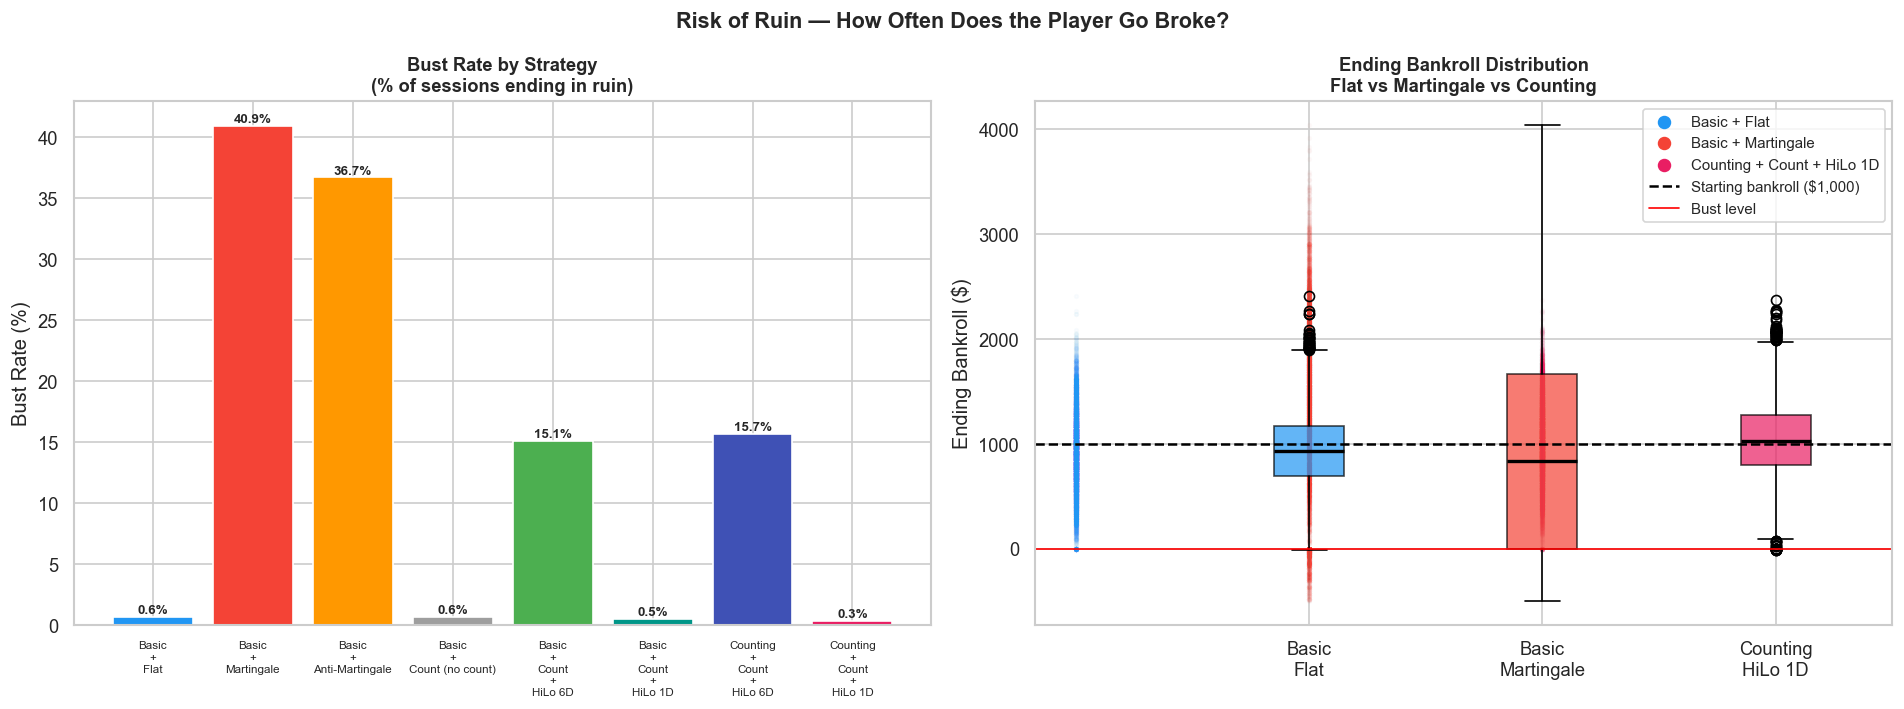

In [11]:
# Risk of ruin analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bust rate comparison across all strategies (excluding random)
plot_labels = [l for l in SESSION_RUNS.values() 
               if l["label"] != "Random + Flat"]
labels = [info["label"] for info in SESSION_RUNS.values() 
          if info["label"] != "Random + Flat"]
colors_ror = [info["color"] for info in SESSION_RUNS.values() 
              if info["label"] != "Random + Flat"]
bust_rates = [sessions[l]["went_bust"].mean() * 100 for l in labels]

bars = axes[0].bar(range(len(labels)), bust_rates, color=colors_ror, edgecolor="white")
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels([l.replace(" + ", "\n+\n") for l in labels], 
                         fontsize=7, rotation= 0)
axes[0].set_title("Bust Rate by Strategy\n(% of sessions ending in ruin)",
                   fontsize=11, fontweight="bold")
axes[0].set_ylabel("Bust Rate (%)")
for bar, val in zip(bars, bust_rates):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    f"{val:.1f}%", ha="center", fontsize=8, fontweight="bold")

# 2. Bankroll trajectory percentiles — Basic Flat vs Martingale vs Counting 1D
trajectory_strategies = {
    "Basic + Flat":              "#2196F3",
    "Basic + Martingale":        "#F44336",
    "Counting + Count + HiLo 1D":"#E91E63",
}

for label, color in trajectory_strategies.items():
    df = sessions[label]
    # Use peak and lowest bankroll to show trajectory range
    axes[1].scatter(
        [label] * len(df),
        df["ending_bankroll"],
        alpha=0.02, color=color, s=5
    )
    axes[1].scatter([], [], color=color, label=label, s=50)

# Better — show distribution as box plot
trajectory_data = [sessions[l]["ending_bankroll"] 
                   for l in trajectory_strategies.keys()]
bp = axes[1].boxplot(trajectory_data, 
                      labels=["Basic\nFlat", "Basic\nMartingale", "Counting\nHiLo 1D"],
                      patch_artist=True,
                      medianprops=dict(color="black", linewidth=2))

for patch, color in zip(bp["boxes"], trajectory_strategies.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].axhline(y=1000, color="black", linestyle="--", 
                linewidth=1.5, label="Starting bankroll ($1,000)")
axes[1].axhline(y=0, color="red", linestyle="-", 
                linewidth=1, label="Bust level")
axes[1].set_title("Ending Bankroll Distribution\nFlat vs Martingale vs Counting",
                   fontsize=11, fontweight="bold")
axes[1].set_ylabel("Ending Bankroll ($)")
axes[1].legend(fontsize=9)

plt.suptitle("Risk of Ruin — How Often Does the Player Go Broke?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Risk of Ruin

Risk of ruin — the probability of losing your entire bankroll in a session — 
varies dramatically across strategies and is largely independent of decision quality.

**Flat betting is the safest.** Basic + Flat: 0.6% bust rate. With $1,000 
starting bankroll, $10 bets, and optimal decisions, you need an extraordinary 
losing streak to go broke in 1,000 hands. The house edge grinds you down 
gradually, not catastrophically.

**Martingale creates catastrophic risk.** 40.9% bust rate — nearly half of all 
sessions end in ruin. The box plot shows why: the distribution has a long lower 
tail reaching zero, while flat betting's distribution stays well above zero in 
almost all sessions. Martingale players who survive a session do well. Those who 
hit a losing streak — and 40.9% do — lose everything.

**Counting on single deck has the lowest risk of any active strategy.** 0.3% bust 
rate — lower even than flat betting — combined with positive expected value. 
The higher bets at favorable counts are placed when the edge is with the player, 
reducing the risk of the bankroll eroding during unfavorable periods.

**The key insight:** risk of ruin is primarily a function of bet sizing relative 
to bankroll, not of decision quality. Martingale's catastrophic bust rate is 
entirely caused by exponentially growing bets during losing streaks — not by 
bad playing decisions. A player using perfect basic strategy still busts 40.9% 
of the time with Martingale. Strategy and bet sizing are independent levers — 
and bet sizing determines survival.

## What This Simulation Can Answer

The simulator is a configurable experimental framework — not just a one-time 
analysis tool. The questions explored here are a subset of what it can investigate.

### Questions We Can Already Answer With Existing Data

**How much does the blackjack payout rule matter?**
Run `--config tough` (6:5 payout) vs `--config vegas` (3:2) with identical 
strategy and compare net profit. The 6:5 rule alone shifts house edge by ~1.4 
percentage points — the single most impactful rule variation for the player.

**What is the optimal session length given a starting bankroll?**
Longer sessions mean more exposure to the house edge but also more time for 
counting to accumulate advantage. The simulation can map bust rate vs session 
length at any bankroll level.

**At what bet spread does counting become profitable in 6 decks?**
Our 1-to-8 spread produces -$8 net in 6 decks. A 1-to-12 or 1-to-16 spread 
would extract more value from high counts. The simulator can test this by 
modifying `CountBasedBetting`.

**How does starting bankroll size affect risk of ruin?**
With $500 starting bankroll and $10 bets, Martingale's bust rate would be 
even higher. With $5,000 and $10 bets, it drops significantly. The simulation 
can map this relationship precisely.

### Questions That Require New Simulations

**Does Omega II counting outperform Hi-Lo in 6 decks?**
Omega II is a more complex multi-level system. The simulator supports it via 
`--counting omega`. A direct comparison would quantify whether added complexity 
produces measurable benefit.

**What is the effect of different penetration depths?**
Casinos control how deep into the shoe they deal before reshuffling. Deeper 
penetration (higher `penetration` config value) gives counters more information. 
The simulation can test penetration from 0.5 to 0.9 and measure counting effectiveness.

**How does KO counting compare to Hi-Lo?**
KO is an unbalanced system that doesn't require true count conversion — simpler 
to use in practice. The simulator supports it via `--counting ko`. A direct 
comparison would show whether the simplicity cost is worth it.

**What is the minimum bankroll required to survive 10,000 hands with counting?**
Risk of ruin as a function of bankroll size — a critical practical question for 
anyone considering counting seriously.

### FUTURE PLANS

A neural network will be trained on the decision data generated by 
this simulator. The key question: **does the model rediscover basic strategy 
and index plays from data alone — without being told the rules?**

The simulator plugs in the trained model as a strategy object with no changes. 
The session analysis framework then evaluates it identically to the hand-coded 
strategies — same metrics, same comparisons, directly comparable results.

## Conclusions

### What the Data Shows

**1. The house edge is real and compounds relentlessly.**
Even optimal play loses $69 per 1,000-hand session on average. 42% of sessions 
end profitable — enough to create the illusion that skill determines short-term 
outcomes. It doesn't. Only aggregate results across hundreds of sessions are meaningful.

**2. Betting systems do not change expected value — they change variance.**
Martingale, Anti-Martingale, and all progressive betting systems are mathematically 
equivalent to flat betting in expected value. What they change is the distribution 
of outcomes: more variance, higher bust risk, same long-run loss. Anyone claiming 
a betting system "beats" the house is misunderstanding this.

**3. Bet variation without information is worthless.**
Count-based betting with no counting system produces identical results to flat 
betting. The bet variation is only valuable because the counting system identifies 
*when* to vary it. Information is the edge — not the betting pattern itself.

**4. Card counting works — but conditions matter enormously.**
In 6 decks, counting reduces losses from -$69 to -$8 net per session. Meaningful 
but not profitable. In single deck with full index plays, the edge flips to +$33 
per session. The difference is deck composition sensitivity — single deck reacts 
faster and more dramatically to card removal. Modern casinos use 6-8 decks 
specifically to reduce counting effectiveness.

**5. Risk of ruin is determined by bet sizing, not decision quality.**
A perfect basic strategy player using Martingale goes broke 40.9% of sessions. 
The same player with flat betting busts 0.6% of the time. Bet sizing and bankroll 
management determine survival — strategy determines the rate of loss or gain 
within that survival window.

**6. The simulation validates its own correctness.**
House edge, dealer bust rate, and blackjack frequency all match known Blackjack 
mathematics. The counting system produces measurable win rate increases at high 
true counts. Index plays produce the expected deviations from basic strategy. 
The results are not artifacts — they reflect the underlying mathematics of the game.

---

*Session analysis complete. Next: neural network trained on simulation 
data to learn optimal strategy without being told the rules.*